<a href="https://colab.research.google.com/github/pellegreeno/Bioestat-stica-2026-/blob/main/tarefa06" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**1. Resumo sobre o dataset:**

Este conjunto de dados, conhecido como Palmer Penguins, foi originalmente criado por Dr. Kristen Gorman e equipe, e é uma alternativa popular ao conjunto de dados Iris para exemplos de ciência de dados. Ele foi disponibilizado publicamente através do repositório GitHub de Allison Horst.

O objetivo do dataset é fornecer medidas morfológicas de três espécies de pinguins encontradas no arquipélago Palmer na Antártica.

**Variáveis do Conjunto de Dados:**
embora não tenhamos analisado variáveis específicas ainda, o conjunto de dados inclui diversas características dos pinguins.

 Duas variáveis chave que podemos destacar são:

**species (espécie):**

Esta variável categórica indica a espécie do pinguim, que pode ser Adelie, Chinstrap ou Gentoo. É fundamental para classificar e comparar os diferentes grupos de pinguins.

**bill_length_mm (comprimento do bico em mm):**

Esta variável numérica representa o comprimento do bico do pinguim em milímetros. É uma medida morfológica importante que pode variar entre as espécies e ser usada para distinção e análise de características físicas.


**2. Um gráfico de dispersão contendo título informativo, identificação clara dos eixos e unidades de medida apropriadas:**

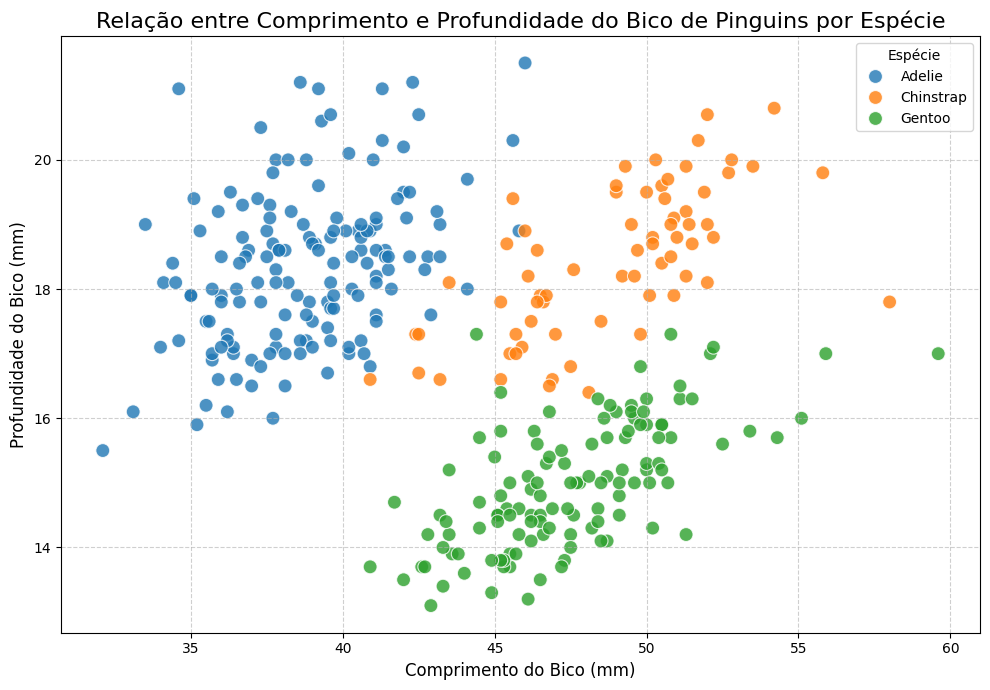

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_penguins_sns = sns.load_dataset("penguins")

# Criar o gráfico de dispersão
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_penguins_sns,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    s=100,  # Tamanho dos pontos
    alpha=0.8 # Transparência dos pontos
)

# Adicionar título informativo
plt.title('Relação entre Comprimento e Profundidade do Bico de Pinguins por Espécie', fontsize=16)

# Identificar claramente os eixos e adicionar unidades de medida
plt.xlabel('Comprimento do Bico (mm)', fontsize=12)
plt.ylabel('Profundidade do Bico (mm)', fontsize=12)

# Adicionar legenda
plt.legend(title='Espécie')

# Adicionar grade para melhor visualização
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar layout e exibir o gráfico
plt.tight_layout()
plt.show()

**3. Resumo sobre regressão linear simples:**

A regressão linear simples é uma ferramenta estatística usada para entender como uma variável se relaciona com outra e tentar prever um resultado a partir disso.
Existe uma variável explicativa (x) e será possível analisar como ela afeta uma variável de resposta (y). O objetivo é encontrar a melhor reta que passa pelo meio desses pontos de dados.
A fórmula clássica que descreve essa reta é: Y = B0 + B1X + e

B0: O valor estimado de y quando x é zero (onde a reta cruza o eixo vertical).

B1: Quanto y muda, em média, para cada unidade que aumento em x.

e: A variação natural dos dados que a reta não consegue explicar, pois nem todos os pontos caem perfeitamente sobre ela.

Na prática, se usa o método dos Mínimos Quadrados Ordinários (MQO) para calcular os coeficientes B0 e B1 de forma a minimizar a soma dos erros ao quadrado.




**4. A estimação, em Python, dos dois coeficientes da reta de regressão linear simples:**

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Remover linhas com valores NaN nas colunas relevantes para a regressão
df_reg = df_penguins_sns.dropna(subset=['bill_length_mm', 'bill_depth_mm']).copy()

# Definir as variáveis X (independente) e y (dependente)
X = df_reg[['bill_length_mm']]
y = df_reg['bill_depth_mm']

# Criar o modelo de regressão linear
model = LinearRegression()

# Ajustar o modelo aos dados
model.fit(X, y)

# Obter os coeficientes
beta_0 = model.intercept_ # Intercepto (β0)
beta_1 = model.coef_[0]   # Coeficiente angular (β1)

print(f"Coeficiente β0 (Intercepto): {beta_0:.4f}")
print(f"Coeficiente β1 (Inclinação/Slope): {beta_1:.4f}")

Coeficiente β0 (Intercepto): 20.8855
Coeficiente β1 (Inclinação/Slope): -0.0850


Isso significa que, para cada milímetro adicional no comprimento do bico, a profundidade do bico é esperada para mudar em aproximadamente -0.0850 milímetros, mantendo outros fatores constantes. O intercepto (20.8855) representa a profundidade do bico esperada se o comprimento do bico fosse zero.


**5. Interpretação Biológica dos Coeficientes de Regressão**

Com base nos coeficientes estimados para a regressão linear simples (onde bill_length_mm é a variável independente e bill_depth_mm é a variável dependente):

*   **Coeficiente β0 (Intercepto):** 20.8855 - Matematicamente, o intercepto representa a profundidade do bico esperada quando o comprimento do bico é zero. No contexto biológico, um comprimento de bico de zero milímetros não é realisticamente possível para um pinguim. Portanto, neste caso, o valor do intercepto (20.8855 mm) não possui uma interpretação biológica direta e prática por si só. Ele é mais um ajuste matemático que permite à reta de regressão melhor se adaptar aos dados observados dentro da faixa real de comprimentos de bico.

*   **Coeficiente β1 (Inclinação/Slope):** -0.0850 - Este coeficiente é biologicamente mais significativo. Ele indica que, para cada aumento de um milímetro (1 mm) no comprimento do bico, a profundidade do bico é esperada para diminuir em aproximadamente 0.0850 milímetros. Isso sugere uma relação inversa entre o comprimento e a profundidade do bico. Ou seja, pinguins com bicos mais longos tendem a ter bicos ligeiramente mais rasos ou finos, enquanto pinguins com bicos mais curtos podem ter bicos proporcionalmente mais profundos ou robustos. Esta relação pode refletir adaptações evolutivas ou diferenças morfológicas entre as espécies de pinguins estudadas (Adelie, Chinstrap, Gentoo), que possuem formatos de bico distintos.

**6. Gráfico de Dispersão com Reta de Regressão Estimada:**


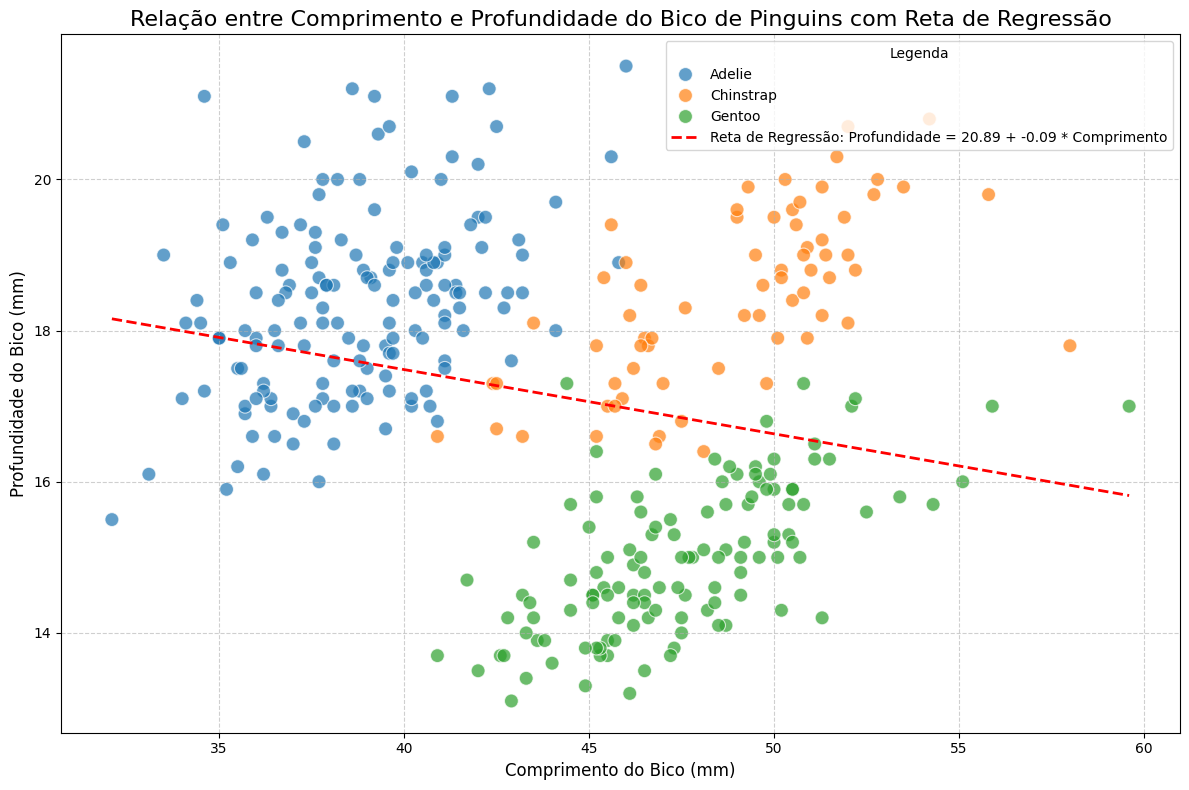

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Carregar o dataset (garantir que esteja disponível)
# Se df_penguins_sns já estiver carregado em memória, esta linha pode ser redundante,
# mas garante a execução independente da célula para o gráfico.
df_penguins_sns = sns.load_dataset("penguins")

# Remover linhas com valores NaN nas colunas relevantes para a regressão
df_reg = df_penguins_sns.dropna(subset=['bill_length_mm', 'bill_depth_mm']).copy()

# Definir as variáveis X (independente) e y (dependente)
X_reg = df_reg[['bill_length_mm']]
y_reg = df_reg['bill_depth_mm']

# Criar e ajustar o modelo de regressão linear
model = LinearRegression()
model.fit(X_reg, y_reg)

# Obter os coeficientes
beta_0 = model.intercept_ # Intercepto (β0)
beta_1 = model.coef_[0]   # Coeficiente angular (β1)

# Criar o gráfico de dispersão
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_penguins_sns,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    s=100,  # Tamanho dos pontos
    alpha=0.7 # Transparência dos pontos
)

# Adicionar título informativo
plt.title('Relação entre Comprimento e Profundidade do Bico de Pinguins com Reta de Regressão', fontsize=16)

# Identificar claramente os eixos e adicionar unidades de medida
plt.xlabel('Comprimento do Bico (mm)', fontsize=12)
plt.ylabel('Profundidade do Bico (mm)', fontsize=12)

# Criar pontos para a reta de regressão usando a faixa de X
x_line = np.linspace(df_reg['bill_length_mm'].min(), df_reg['bill_length_mm'].max(), 100)
y_line = beta_0 + beta_1 * x_line

# Plotar a reta de regressão
plt.plot(x_line, y_line, color='red', linestyle='--', linewidth=2,
         label=f'Reta de Regressão: Profundidade = {beta_0:.2f} + {beta_1:.2f} * Comprimento')

# Adicionar legenda (atualizada para incluir a reta)
plt.legend(title='Legenda', loc='upper right')

# Adicionar grade para melhor visualização
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar layout e exibir o gráfico
plt.tight_layout()
plt.show()

 **7. Correlação linear de Pearson:**

A Correlação Linear de Pearson é uma medida estatística que diz o quão forte e em que direção duas variáveis numéricas estão linearmente relacionadas. Em termos mais simples:

Força: Ela nos informa o quão bem os pontos de dados se ajustam a uma linha reta. Um valor próximo de +1 ou -1 indica uma relação linear muito forte, e um valor próximo de zero sugere uma relação linear fraca.

Direção: O sinal do coeficiente indica a direção da relação:
- Positivo (+): Se uma variável aumenta, a outra também tende a aumentar.
- Negativo (-): Se uma variável aumenta, a outra tende a diminuir.



**8. O cálculo do coeficiente de correlação de Pearson entre as duas variáveis e a interpretação do resultado:**

In [ ]:
# Calcular o coeficiente de correlação de Pearson
penguin_correlation = df_reg['bill_length_mm'].corr(df_reg['bill_depth_mm'])

print(f"Coeficiente de Correlação de Pearson entre as variáveis: {penguin_correlation:.4f}")

Coeficiente de Correlação de Pearson entre as variáveis: -0.2351


O coeficiente de correlação de Pearson calculado entre comprimento do bico (bill_length_mm) e profundidade do bico (bill_depth_mm) é de -0.2351.



*   **Valor (-0.2351):** Este valor é relativamente próximo de zero, mas é negativo. Isso indica uma correlação linear fraca e negativa entre as duas variáveis.

*   **Direção (Negativa):** O sinal negativo confirma o que já observamos na regressão linear: à medida que o comprimento do bico de um pinguim aumenta, a profundidade do bico tende a diminuir levemente. Contudo, a baixa magnitude do coeficiente (próxima de zero) sugere que essa relação não é muito forte. Em outras palavras, o comprimento do bico explica apenas uma pequena parte da variação na profundidade do bico de forma linear.

*   **Contexto Biológico:** Uma correlação fraca e negativa pode ser esperada, especialmente porque o dataset palmerpenguins inclui múltiplas espécies de pinguins, cada uma com morfologias de bico distintas. A relação entre comprimento e profundidade pode variar consideravelmente entre as espécies, e uma análise agregada como esta pode mascarar relações mais fortes dentro de cada espécie ou indicar que outros fatores são mais influentes na determinação da profundidade do bico.

**9. Um comentário sobre a direção da correlação observada:**

A correlação observada (-0.2351) é negativa e fraca, indicando que valores maiores de uma variável tendem a estar associados a valores menores da outra. Assim, as duas variáveis apresentam uma tendência de variação em sentidos opostos.


 **10. A explicação de que uma correlação igual ou próxima de zero indica ausência de relação linear, mas não necessariamente ausência de qualquer relação entre as variáveis:**
  
Uma correlação próxima de zero significa apenas que não dá para desenhar uma linha reta que acompanhe os dados. Ela não significa que as variáveis não tenham relação entre si.
Muitos processos biológicos seguem curvas em vez de linhas retas.
É importante não olhar apenas o número da correlação. O gráfico deve ser montado para não haverem conclusões incertas: o valor r = 0 diz apenas que não há uma reta, mas o gráfico mostra se existe outro tipo de padrão acontecendo.

**11. A inclusão, em células de texto/Markdown, das fórmulas da regressão linear simples e da correlação de Pearson. Não é necessário apresentar a demonstração matemática dessas fórmulas.**

### Fórmula da Regressão Linear Simples
A regressão linear simples modela a relação entre duas variáveis com uma linha reta, expressa pela equação:

$$ \hat{y} = \beta_0 + \beta_1 x $$

Onde:
- $ \hat{y} $: É o valor predito da variável dependente.
- $ \beta_0 $: É o coeficiente de intercepção (intercepto), que representa o valor de $ \hat{y} $ quando $ x = 0 $.
- $ \beta_1 $: É o coeficiente de inclinação (slope), que representa a variação em $ \hat{y} $ para cada unidade de mudança em $ x $.
- $ x $: É o valor da variável independente.

Os coeficientes $ \beta_0 $ e $ \beta_1 $ são estimados usando o método dos Mínimos Quadrados Ordinários (MQO) para minimizar a soma dos quadrados dos resíduos.

### Fórmula do Coeficiente de Correlação de Pearson ($ r $)
O coeficiente de correlação de Pearson mede a força e a direção da relação linear entre duas variáveis contínuas ($ x $ e $ y $). Ele é calculado pela seguinte fórmula:

$$ r = \frac{n(\sum xy) - (\sum x)(\sum y)}{\sqrt{[n\sum x^2 - (\sum x)^2][n\sum y^2 - (\sum y)^2]}} $$

Onde:
- $ n $: É o número de pares de dados.
- $ \sum xy $: É a soma dos produtos de $ x $ e $ y $.
- $ \sum x $: É a soma dos valores de $ x $.
- $ \sum y $: É a soma dos valores de $ y $.
- $ \sum x^2 $: É a soma dos quadrados dos valores de $ x $.
- $ \sum y^2 $: É a soma dos quadrados dos valores de $ y $.

O valor de $ r $ varia de -1 a +1:
- $ r = 1 $: Correlação linear positiva perfeita.
- $ r = -1 $: Correlação linear negativa perfeita.
- $ r = 0 $: Ausência de correlação linear.

**Breve conclusão sobre a relação observada entre as variáveis e sobre como a regressão linear simples e a correlação de Pearson podem auxiliar na interpretação de dados biológicos.**

A análise mostrou uma correlação linear negativa e fraca entre as variáveis estudadas, com coeficiente de Pearson igual a -0,2351. Isso indica uma tendência em que valores maiores de uma variável estão associados a valores menores da outra, mas essa associação linear é pouco intensa. A regressão linear simples permite visualizar e quantificar essa tendência por meio de uma reta, enquanto a correlação de Pearson permite avaliar a direção e a intensidade da associação linear. É importante destacar que uma correlação fraca ou próxima de zero não significa necessariamente que não exista relação entre as variáveis, pois pode haver uma associação não linear que não seja identificada pelo coeficiente de Pearson.